# Demand Forecasting in Supply Chain Management

Uses a Random Forest to forecast demand from historical sales data.

The default dataset is `Walmart_Sales.csv` (weekly sales across 45 Walmart stores). To use a different file, update the `CONFIG` cell below.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Configuration

Point `CSV_PATH` at your own dataset and map its column names. The defaults below work with the bundled Walmart dataset.

In [21]:
CSV_PATH = 'data/Walmart_Sales.csv'

DATE_COL    = 'Date'
DEMAND_COL  = 'Weekly_Sales'
PRODUCT_COL = 'Store'          # set to None if your data has no product/store column
HOLIDAY_COL = 'Holiday_Flag'   # set to None if unavailable

SELECTED_PRODUCT = 1           # pick a single store/product, or None to aggregate
TEST_SIZE = 10                 # last N rows used for evaluation
FORECAST_STEPS = 10            # how many future periods to predict

## Load the data

Parses dates, drops any rows with missing demand, and filters down to a single product if one was selected.

In [22]:
df = pd.read_csv(CSV_PATH)

# Parse dates. dayfirst handles the DD-MM-YYYY format in the Walmart file.
df[DATE_COL] = pd.to_datetime(df[DATE_COL], dayfirst=True, errors='coerce')
df = df.dropna(subset=[DATE_COL, DEMAND_COL])

rename_map = {DATE_COL: 'Date', DEMAND_COL: 'Demand'}
if PRODUCT_COL:
    rename_map[PRODUCT_COL] = 'Product'
if HOLIDAY_COL:
    rename_map[HOLIDAY_COL] = 'Holiday'
df = df.rename(columns=rename_map)

if SELECTED_PRODUCT is not None and 'Product' in df.columns:
    df = df[df['Product'] == SELECTED_PRODUCT].copy()
elif 'Product' in df.columns:
    agg = {'Demand': 'sum'}
    if 'Holiday' in df.columns:
        agg['Holiday'] = 'max'
    df = df.groupby('Date', as_index=False).agg(agg)

df = df.sort_values('Date').reset_index(drop=True)

print(f'Rows: {len(df)}')
print(f'Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
df.head()

Rows: 143
Date range: 2010-02-05 to 2012-10-26


,Product,Date,Demand,Holiday,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


## Feature engineering

Calendar features (month, week-of-year, etc.) give the model a sense of seasonality. Lag and rolling features let it pick up on recent trends.

In [23]:
df['Month']      = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['Date'].dt.quarter

df['Lag_1'] = df['Demand'].shift(1)
df['Lag_2'] = df['Demand'].shift(2)
df['Lag_4'] = df['Demand'].shift(4)

df['Rolling_4']  = df['Demand'].shift(1).rolling(4).mean()
df['Rolling_12'] = df['Demand'].shift(1).rolling(12).mean()

if 'Holiday' not in df.columns:
    df['Holiday'] = 0
else:
    df['Holiday'] = df['Holiday'].fillna(0).astype(int)

df = df.dropna().reset_index(drop=True)
df.head()

,Product,Date,Demand,Holiday,Temperature,Fuel_Price,CPI,Unemployment,Month,WeekOfYear,Quarter,Lag_1,Lag_2,Lag_4,Rolling_4,Rolling_12
0,1,2010-04-30,1425100.71,0,67.41,2.780,210.389546,7.808,4,17,2,1391256.12,1466058.28,1594968.28,1.499425e+06,1.514695e+06
1,1,2010-05-07,1603955.12,0,72.55,2.835,210.339968,7.808,5,18,2,1425100.71,1391256.12,1545418.53,1.456958e+06,1.496479e+06
2,1,2010-05-14,1494251.50,0,74.78,2.854,210.337426,7.808,5,19,2,1603955.12,1425100.71,1466058.28,1.471593e+06,1.493312e+06
3,1,2010-05-21,1399662.07,0,76.44,2.826,210.617093,7.808,5,20,2,1494251.50,1603955.12,1391256.12,1.478641e+06,1.483503e+06
4,1,2010-05-28,1432069.95,0,80.44,2.759,210.896761,7.808,5,21,2,1399662.07,1494251.50,1425100.71,1.480742e+06,1.482664e+06


## Quick look at the data

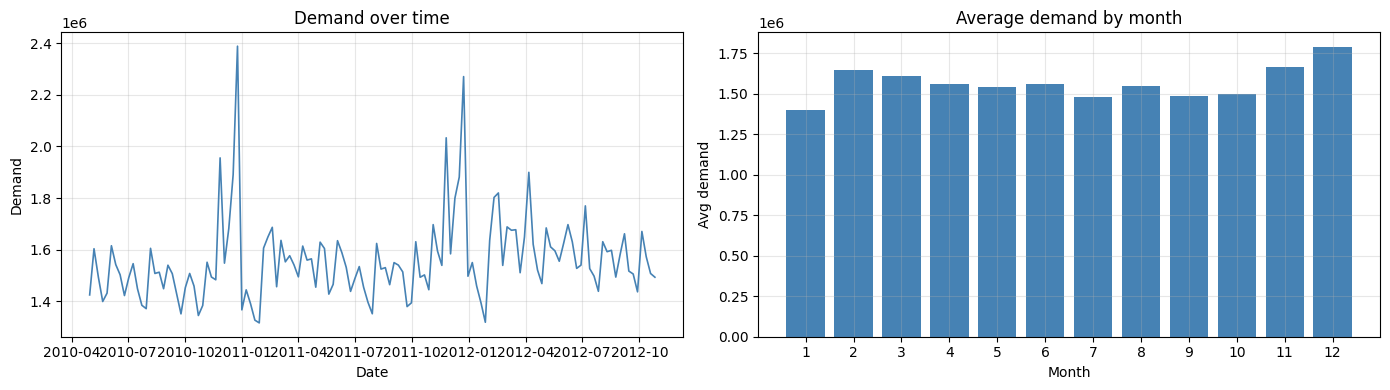

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df['Date'], df['Demand'], color='steelblue', linewidth=1.2)
axes[0].set_title('Demand over time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Demand')

monthly_avg = df.groupby('Month')['Demand'].mean()
axes[1].bar(monthly_avg.index, monthly_avg.values, color='steelblue')
axes[1].set_title('Average demand by month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg demand')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## Train / test split

For time series we always split chronologically. The last `TEST_SIZE` rows are held out and the model only sees older data during training.

In [25]:
features = ['Month', 'WeekOfYear', 'Quarter',
            'Lag_1', 'Lag_2', 'Lag_4',
            'Rolling_4', 'Rolling_12', 'Holiday']

if len(df) <= TEST_SIZE + 5:
    raise ValueError(f'Not enough data. Need more than {TEST_SIZE + 5} rows, got {len(df)}.')

train = df.iloc[:-TEST_SIZE]
test  = df.iloc[-TEST_SIZE:]

X_train, y_train = train[features], train['Demand']
X_test,  y_test  = test[features],  test['Demand']

print(f'Training on {len(train)} rows, testing on {len(test)} rows')
print(f'Train period: {train["Date"].min().date()} to {train["Date"].max().date()}')
print(f'Test period : {test["Date"].min().date()} to {test["Date"].max().date()}')

Training on 121 rows, testing on 10 rows
Train period: 2010-04-30 to 2012-08-17
Test period : 2012-08-24 to 2012-10-26


## Train the model

Random Forest is a good fit here: it handles non-linear patterns, doesn't need feature scaling, and gives us feature importances for free.

In [26]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


## Evaluate on the test set

- **MAE**: average absolute error in the same units as demand
- **RMSE**: penalises large errors more heavily
- **MAPE**: average percentage error, easy to compare across datasets
- **R²**: 1.0 is perfect, 0.0 means no better than predicting the mean

In [27]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

# MAPE skips rows where the actual is zero to avoid division errors
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100 if mask.any() else np.nan

print(f'MAE  : {mae:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'MAPE : {mape:.2f}%')
print(f'R^2  : {r2:.3f}')

MAE  : 50,885.87
RMSE : 62,392.09
MAPE : 3.28%
R^2  : 0.253


## Actual vs predicted

In [28]:
results = test[['Date', 'Demand']].copy()
results['Predicted'] = y_pred.round(2)
results['Error']     = (results['Demand'] - results['Predicted']).round(2)
results

,Date,Demand,Predicted,Error
121,2012-08-24,1494122.38,1542301.29,-48178.91
122,2012-08-31,1582083.40,1569538.54,12544.86
123,2012-09-07,1661767.33,1570673.18,91094.15
124,2012-09-14,1517428.87,1597498.78,-80069.91
125,2012-09-21,1506126.06,1493222.83,12903.23
126,2012-09-28,1437059.26,1535387.79,-98328.53
127,2012-10-05,1670785.97,1572115.03,98670.94
128,2012-10-12,1573072.81,1577861.33,-4788.52
129,2012-10-19,1508068.77,1549371.28,-41302.51
130,2012-10-26,1493659.74,1472682.59,20977.15


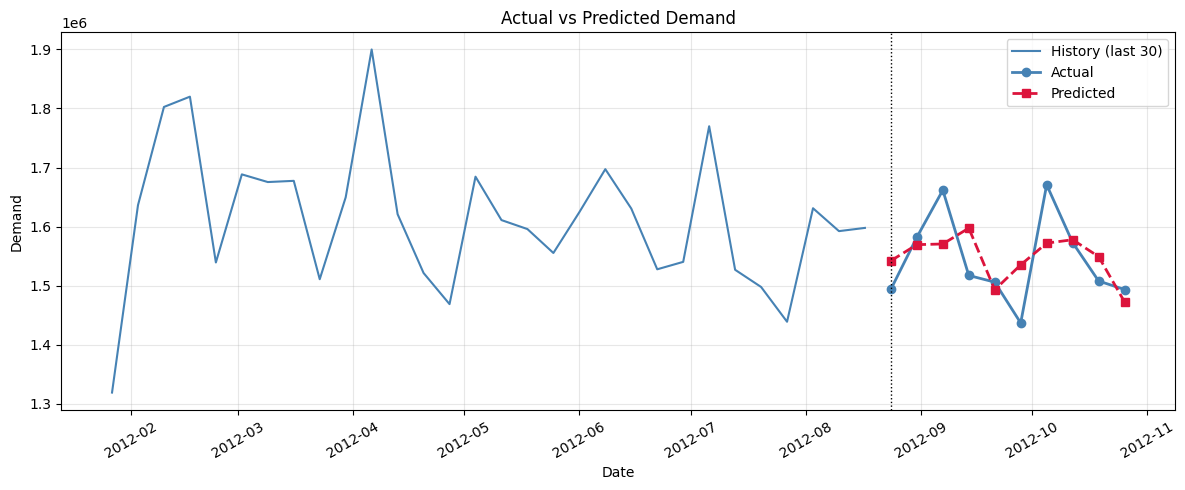

In [29]:
plt.figure(figsize=(12, 5))
plt.plot(train['Date'].tail(30), y_train.tail(30),
         color='steelblue', linewidth=1.5, label='History (last 30)')
plt.plot(test['Date'], y_test.values,
         color='steelblue', linewidth=2, marker='o', label='Actual')
plt.plot(test['Date'], y_pred,
         color='crimson', linewidth=2, linestyle='--', marker='s', label='Predicted')
plt.axvline(test['Date'].iloc[0], color='black', linestyle=':', linewidth=1)
plt.title('Actual vs Predicted Demand')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Feature importance

Which inputs the model leans on most.

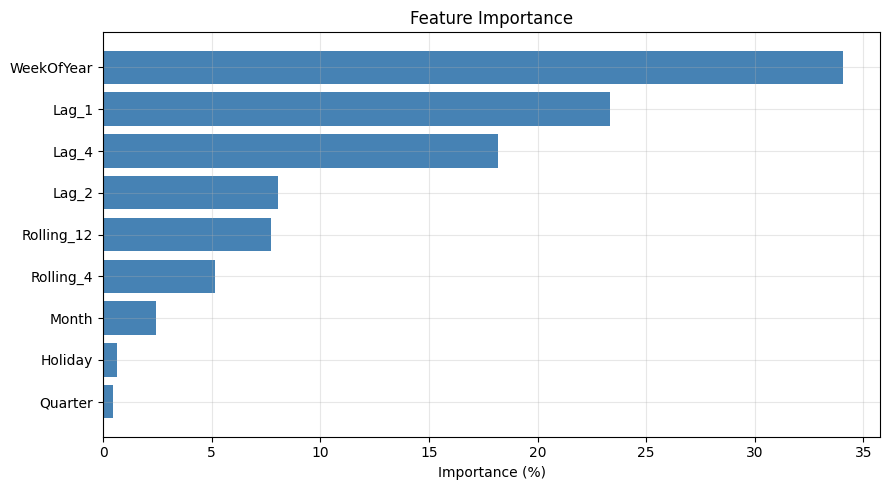

In [30]:
importances = (pd.Series(model.feature_importances_, index=features)
                 .sort_values(ascending=True))

plt.figure(figsize=(9, 5))
plt.barh(importances.index, importances.values * 100, color='steelblue')
plt.xlabel('Importance (%)')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## Forecast future demand

Once we're happy with the model, we retrain it on all the data and predict the next `FORECAST_STEPS` periods. This is a recursive forecast: each prediction gets fed back as the lag input for the next step.

In [31]:
final_model = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=2,
    random_state=42, n_jobs=-1,
)
final_model.fit(df[features], df['Demand'])

# Figure out the gap between consecutive dates so we can extend forward correctly.
median_gap = df['Date'].diff().median()
if pd.isna(median_gap):
    median_gap = pd.Timedelta(days=7)

history = df[['Date', 'Demand']].copy()
predictions = []

for step in range(1, FORECAST_STEPS + 1):
    next_date = history['Date'].iloc[-1] + median_gap
    recent = history['Demand']

    row = {
        'Month'     : next_date.month,
        'WeekOfYear': int(next_date.isocalendar()[1]),
        'Quarter'   : next_date.quarter,
        'Lag_1'     : recent.iloc[-1],
        'Lag_2'     : recent.iloc[-2] if len(recent) >= 2 else recent.iloc[-1],
        'Lag_4'     : recent.iloc[-4] if len(recent) >= 4 else recent.mean(),
        'Rolling_4' : recent.tail(4).mean(),
        'Rolling_12': recent.tail(12).mean(),
        'Holiday'   : 0,
    }
    pred = float(final_model.predict(pd.DataFrame([row])[features])[0])
    predictions.append({'Date': next_date, 'Forecast': round(pred, 2)})
    history = pd.concat(
        [history, pd.DataFrame([{'Date': next_date, 'Demand': pred}])],
        ignore_index=True,
    )

forecast = pd.DataFrame(predictions)
forecast

,Date,Forecast
0,2012-11-02,1632325.41
1,2012-11-09,1573584.82
2,2012-11-16,1543353.78
3,2012-11-23,1802884.62
4,2012-11-30,1788434.55
5,2012-12-07,1801472.26
6,2012-12-14,1869122.29
7,2012-12-21,1987746.57
8,2012-12-28,1706476.24
9,2013-01-04,1593377.04


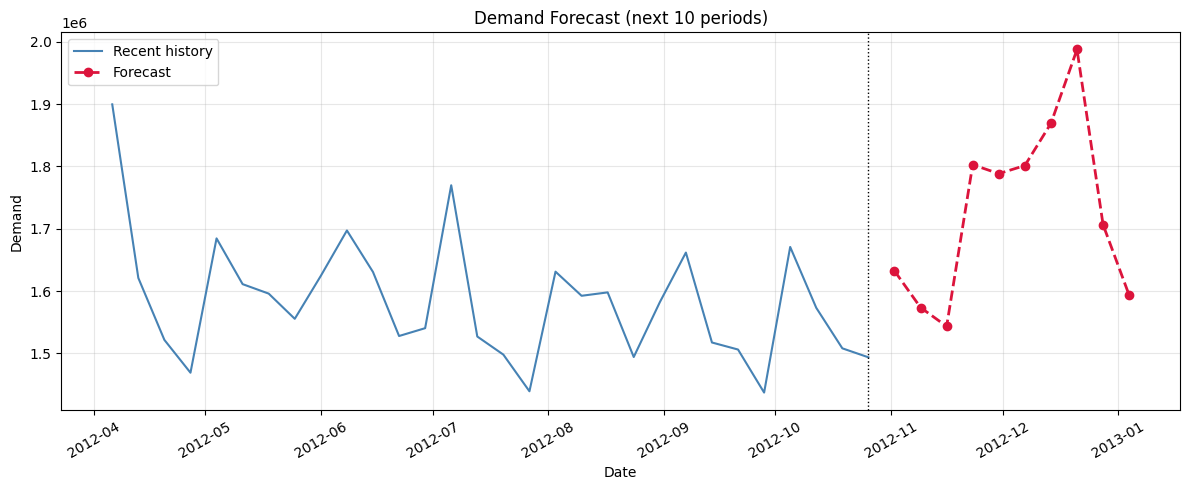

In [32]:
recent_history = df.tail(30)

plt.figure(figsize=(12, 5))
plt.plot(recent_history['Date'], recent_history['Demand'],
         color='steelblue', linewidth=1.5, label='Recent history')
plt.plot(forecast['Date'], forecast['Forecast'],
         color='crimson', linewidth=2, linestyle='--', marker='o', label='Forecast')
plt.axvline(df['Date'].iloc[-1], color='black', linestyle=':', linewidth=1)
plt.title(f'Demand Forecast (next {FORECAST_STEPS} periods)')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Save outputs

In [33]:
results.to_csv('outputs/test_predictions.csv', index=False)
forecast.to_csv('outputs/forecast.csv', index=False)
print('Saved test_predictions.csv and forecast.csv')

Saved test_predictions.csv and forecast.csv
